In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from credit_pipeline.data import load_dataset
from credit_pipeline.training import optimize_model_fast, create_pipeline
from credit_pipeline.evaluate import get_metrics

from credit_pipeline.explainability import *

%load_ext autoreload
%autoreload 2

/home/hiaac/Documents/code/credit_pipeline/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this notebook we will leverage explainability techniques to understand a RandomForest classifier. Using the Taiwan dataset, we will verify the most relevant features using two methodologies. Furthermore, we will also analyze explanations of particular samples to understand the model's behavior on a local level.

First we load the data and fit the model.

In [2]:
seed = 0
df = load_dataset("taiwan")
X = df.drop(columns=["DEFAULT"])
y = df["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# split the training set into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

pipeline = create_pipeline(
    X_train,
    y_train,
    classifier = RandomForestClassifier(),
    cat_cols = "infer",
    onehot = True,
    onehotdrop = False,
    normalize = True,
    do_EBE = True,
)
pipeline.fit(X_train, y_train)



background_samples = 100
n_samples = 1000
X_background = X_train.sample(n=background_samples, random_state=seed)
X_sample = X_train.sample(n=n_samples, random_state=seed)

## Global Importances

The following is the implementation of a simple parallel coordinates plot.

In [3]:
def parallel_coordinates(
    df,
    columns,
    columns_ranges = None,
    columns_tick_format = None,
    columns_names = None,
    color_column = None,
    color_mapper = None,
    name_mapper = None,
    legend_order = None,
    title = None
):
    """
    Simple parallel coordinates to plot the projection results.
    """
    norm_df = df.copy() # dataframe will be normalized

    fig, axes = plt.subplots(len(columns)-1, 1, sharex=False, figsize=(5,10))

    if columns_ranges is None:
        columns_ranges = [None for _ in columns]
    if columns_tick_format is None:
        columns_tick_format = [lambda x : np.round(x, 1) for _ in columns]

    # Get min, max and range for each column
    # Normalize the data for each column
    min_max_range = {}
    for i, col in enumerate(columns):
        if columns_ranges[i] is None:
            col_max = df[col].max()
            col_min = df[col].min()
        else:
            col_max = columns_ranges[i][1]
            col_min = columns_ranges[i][0]

        min_max_range[col] = [col_min, col_max]
        col_range = col_max - col_min
        if col_range == 0:
            col_range = 1
        norm_df[col] = (df[col] - col_min) / col_range

    # Invert to plot first columns at the top
    x = list(range(len(columns)))[::-1]
    axx = axes[0].twiny()
    # Plot each row
    if color_column is None:
        for i, ax in enumerate(axes):
            for idx in norm_df.index:
                ax.plot(norm_df.loc[idx, columns], x, c = "#80b1d3", lw = 3)
        for idx in norm_df.index:
            axx.plot(norm_df.loc[idx, columns], x, c = "#80b1d3", lw = 3)
    else:
        color_values = norm_df[color_column].unique()
        colormap = plt.get_cmap("Paired")
        if color_column is not None and color_mapper is None:
            color_mapper = {color_value: colormap(i) for i, color_value in enumerate(color_values)}

        for ii, value in enumerate(color_values):
            df_value = norm_df[norm_df[color_column] == value]
            for i, ax in enumerate(axes[:-1]):
                for idx in df_value.index:
                    ax.plot(df_value.loc[idx, columns], x, alpha = 0.85, lw = 5, label = value, c = color_mapper[value])
            for idx in df_value.index:
                axx.plot(df_value.loc[idx, columns], x, alpha = 0.85, lw = 5, label = value, c = color_mapper[value])
    
    for i, ax in enumerate(axes):
        ax.set_ylim([x[i+1], x[i]])
        ax.set_xlim([-0.05, 1.05])
        xticks = ax.get_xticks()
        col_min = min_max_range[columns[i]][0]
        col_max = min_max_range[columns[i]][1]
        col_range = col_max - col_min
        format_ = columns_tick_format[i]
        ax.set_xticklabels([format_(yi * col_range  + col_min)  for yi in xticks], fontsize = 14)
    
    axes[0].set_xlim([-0.05, 1.05])

    for i, ax in enumerate(axes):
        #ax.yaxis.set_major_locator(ticker.FixedLocator([i+1]))
        ax.set_yticks([len(axes) - i])
        ax.set_yticklabels([columns_names[i]], fontsize = 18)

    axes[-1].set_yticks([0, 1])
    axes[-1].set_yticklabels([columns_names[-2], columns_names[-1]], fontsize = 18)

    # tick for right side of last axis
    axx.set_facecolor("none")
    xticks = axes[-1].get_xticks()
    col_min = min_max_range[columns[len(axes)]][0]
    col_max = min_max_range[columns[len(axes)]][1]
    col_range = col_max - col_min
    format_ = columns_tick_format[len(axes)]
    if format_ is None:
        axx.set_xticklabels([np.round((yi * col_range +  col_min), 1)  for yi in xticks], fontsize = 14)
    else:
        axx.set_xticklabels([format_(yi * col_range +  col_min)  for yi in xticks], fontsize = 14)
    #axx.xaxis.tick_top()
    #axx.set_axisbelow(True)
    #axx.set_xlim([-0.05, 1.05])
    #axx.spines['top'].set_visible(False)
    #axx.spines['bottom'].set_visible(False)

    for ax in list(axes) + [axx]:
        ax.set_facecolor("none")
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)


    
    if title:
        plt.suptitle(title, y = 1, fontsize = 20)
    # Remove space between subplots
    plt.subplots_adjust(hspace=0)

    if color_column is not None:
        handles = [
            mpatches.Patch(color=to_hex(color_mapper[value]), label=name_mapper[value]) for value in legend_order
        ]
        plt.legend(handles = handles, bbox_to_anchor=(1.3, 1), ncol = len(legend_order))

Let's use SHAP to obtain global feature importances.

In [ ]:
explainer = ShapPipelineExplainer(
    pipeline,
    X_train.sample(n = background_samples, random_state = seed),
    method_explain="pred",
    threshold = 0.5
)

importances = explainer(X_train.sample(n = n_samples, random_state = seed))
shap_features_names = importances.columns.tolist()
shap_features_importance = importances.abs().mean().values
shap_features_importance = pd.DataFrame(
    np.array(shap_features_importance).reshape(1, -1), columns=shap_features_names
)

In [4]:
def filter_importance_features(df_importance):
    """Get the median (abs) importance of each feature and select the 10 featuers with highest median importance."""
    importance_values = df_importance.values
    median_importance = np.median(np.abs(importance_values), axis=0)
    sorted_idx = np.argsort(median_importance)[::-1][:10]
    features = df_importance.columns.tolist()
    features_sorted = np.array(features)[sorted_idx]
    return features_sorted

In [5]:
def plot_pc_importances(df_importance, title = ""):
    features = filter_importance_features(df_importance).tolist()
    n_f = len(features)
    imp_range = [
        df_importance[features].values.min(), df_importance[features].values.max()
    ]
    tick_format = lambda x : f"{x:.2f}"
    parallel_coordinates(
        df_importance,
        features,
        columns_ranges = [imp_range for _ in range(n_f)],
        columns_tick_format = [tick_format for _ in range(n_f)],
        columns_names = features,
        title = title
    )

In [ ]:
plot_pc_importances(
    shap_features_importance, "SHAP\nFeature Importances",
)

## PDP

In [15]:
def plot_pdp(model_list, X, selected_feature):
    fig, axs = plt.subplots(nrows = 1, ncols = len(model_list), figsize = (int(4 * len(model_list)), 4))
    if len(model_list) == 1:
        axs = [axs]
    

    for i, model in enumerate(model_list):
        explainer = PartialDependencePipeline(model)
        pdp = explainer(X, selected_feature)
        if len(selected_feature) == 1:
            name = selected_feature[0]
            pdp["values"] = pdp["values"][0]
            pdp["prediction"] = pdp["prediction"][0]
            pdp["deciles"] = pdp["deciles"][0]
        
            axs[i].plot(pdp["values"], pdp["prediction"])
            axs[i].set_title(model[-1].__class__.__name__)
            axs[i].set_xlabel(name)
            axs[i].set_ylabel("Probability of Default")

            for decile in pdp["deciles"]:
                axs[i].axvline(decile, ymin = 0, ymax = 0.05, color = "#606060", alpha = 0.9)

        else:
            assert len(selected_feature) == 2
            pdp["prediction"] = pdp["prediction"][0, :, :]
            axs[i].imshow(pdp["prediction"], cmap = "viridis", aspect = "auto")


    
    plt.suptitle(f"Partial Dependence Plot for {selected_feature}", fontsize = 16)
    plt.tight_layout()

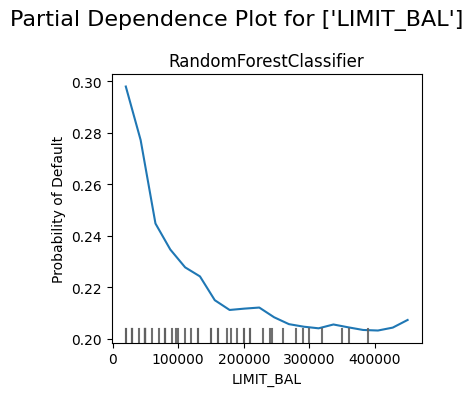

In [17]:
plot_pdp([pipeline], X_sample, ["LIMIT_BAL"])

## ICE

In [26]:
def plot_ice(model_list, X, selected_feature, color_by = None):
    fig, axs = plt.subplots(nrows = 1, ncols = len(model_list), figsize = (int(4* len(model_list)), 4))
    if len(model_list) == 1:
        axs = [axs]


    if color_by is not None:
        vmax = np.quantile(X[color_by], 0.95)
        color_map = lambda x : plt.cm.plasma_r(x / vmax)
    else:
        color_map = lambda x : "#80b1d3"

    
    for i, model in enumerate(model_list):
        explainer = PartialDependencePipeline(model, kind = "individual")
        pdp = explainer(X, selected_feature)
        
        if len(selected_feature) == 1:
            pdp["values"] = pdp["values"][0]
            pdp["prediction"] = pdp["prediction"][0]
            pdp["deciles"] = pdp["deciles"][0]
        
        # reset to all lines start at 0
        pdp["prediction"] = pdp["prediction"] - pdp["prediction"][:, 0][:, np.newaxis]
        for j in range(X.shape[0]):
            c = color_map(X[color_by].values[j])
            axs[i].plot(pdp["values"], pdp["prediction"][j, :], c = c, alpha = 0.4)
        axs[i].set_title(model[-1].__class__.__name__)
        axs[i].set_xlabel(selected_feature[0])
        axs[i].set_ylabel("Probability of Default")

        for decile in pdp["deciles"]:
            axs[i].axvline(decile, ymin = 0, ymax = 0.05, color = "#606060", alpha = 0.9)


    if color_by is not None:
        sm = plt.cm.ScalarMappable(cmap = plt.cm.plasma_r, norm = plt.Normalize(vmin = 0, vmax = vmax))
        #sm.set_array(
        cbar = plt.colorbar(sm, ax = axs, orientation = "horizontal")
        cbar.set_label(color_by)
        
        cbar.ax.set_position([0.1, -0.2, 0.8, 0.05])
        # change ticks to be in scientific notation
        ticks = cbar.get_ticks()[::2]
        cbar.set_ticks(ticks)
        ticks = ["{:.1E}".format(t) for t in ticks]
        cbar.set_ticklabels(ticks)

    plt.suptitle(f"Individual Conditional Expectation for {selected_feature[0]}", fontsize = 16)          
    plt.tight_layout(w_pad=0.3)

/tmp/ipykernel_51238/2241322151.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.3)


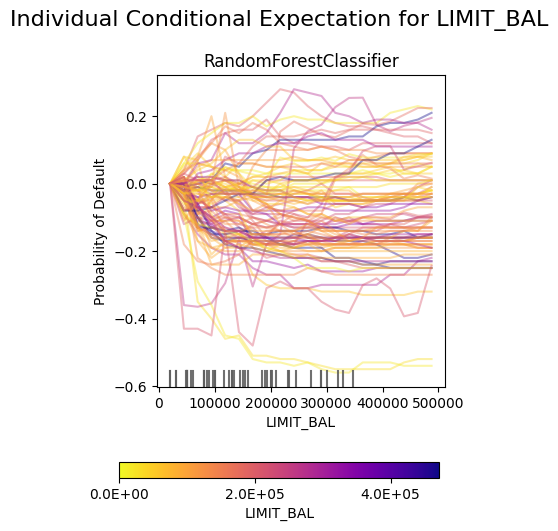

In [28]:
plot_ice([pipeline], X_sample.head(100), ["LIMIT_BAL"], color_by="LIMIT_BAL")

## SHAP and LIME

Ref for shap handling of categorical features: https://github.com/shap/shap/issues/397

In [8]:
shap_explainer = ShapPipelineExplainer(pipeline, X_sample, method_explain="prob")
lime_explainer = LimePipelineExplainer(pipeline, X_sample, method_explain="prob")

{14: ['Female', 'Male'], 15: ['University', 'Graduate School', 'High School', 'Unknown', 'Others'], 16: ['Married', 'Single', 'Others'], 17: [0.0, 2.0, 1.0, -2.0, -1.0, 3.0, 6.0, 8.0, 5.0, 4.0, 7.0], 18: [0.0, 2.0, -2.0, -1.0, 5.0, 4.0, 1.0, 3.0, 7.0, 6.0, 8.0], 19: [-1.0, 0.0, 2.0, -2.0, 7.0, 3.0, 4.0, 6.0, 5.0, 8.0, 1.0], 20: [0.0, -1.0, -2.0, 7.0, 2.0, 3.0, 5.0, 4.0, 6.0, 8.0, 1.0], 21: [0.0, -1.0, -2.0, 6.0, 3.0, 2.0, 7.0, 4.0, 5.0, 8.0], 22: [0.0, -1.0, -2.0, 5.0, 2.0, 7.0, 3.0, 6.0, 4.0, 8.0]}


{14: ['Female', 'Male'], 15: ['University', 'Graduate School', 'High School', 'Unknown', 'Others'], 16: ['Married', 'Single', 'Others'], 17: ['0.0', '2.0', '1.0', '-2.0', '-1.0', '3.0', '6.0', '8.0', '5.0', '4.0', '7.0'], 18: ['0.0', '2.0', '-2.0', '-1.0', '5.0', '4.0', '1.0', '3.0', '7.0', '6.0', '8.0'], 19: ['-1.0', '0.0', '2.0', '-2.0', '7.0', '3.0', '4.0', '6.0', '5.0', '8.0', '1.0'], 20: ['0.0', '-1.0', '-2.0', '7.0', '2.0', '3.0', '5.0', '4.0', '6.0', '8.0', '1.0'], 21: ['0.0', '-1.0', '-2.0', '6.0', '3.0', '2.0', '7.0', '4.0', '5.0', '8.0'], 22: ['0.0', '-1.0', '-2.0', '5.0', '2.0', '7.0', '3.0', '6.0', '4.0', '8.0']}


Text(0.5, 0.98, 'LIME Explanation | Prob(Y = 1) = 0.19')

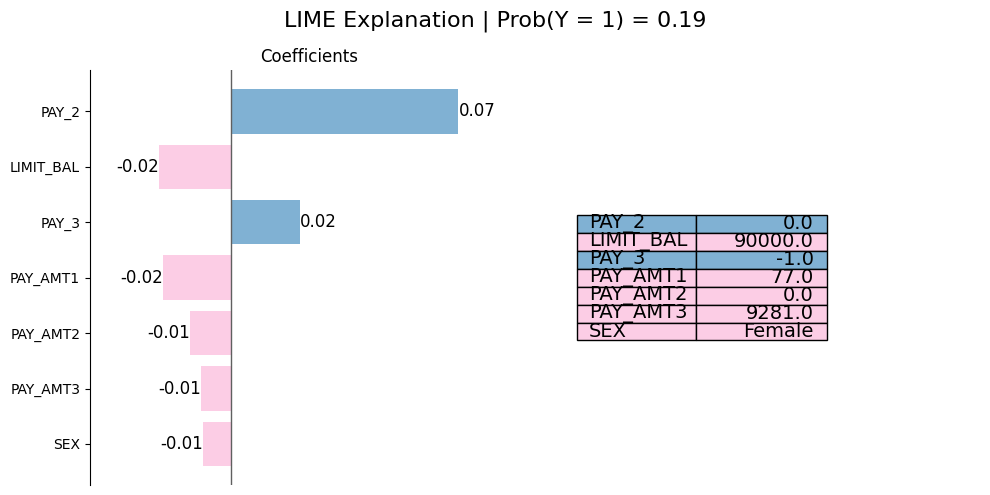

In [6]:
lime_explainer.plot_explanation(X_train.iloc[[2]])
prob = pipeline.predict_proba(X_train.iloc[[2]])[0, 1]
plt.suptitle(f"LIME Explanation | Prob(Y = 1) = {prob:.2f}", fontsize = 16)

Text(0.5, 0.98, 'SHAP Explanation | Prob(Y = 1) = 0.19')

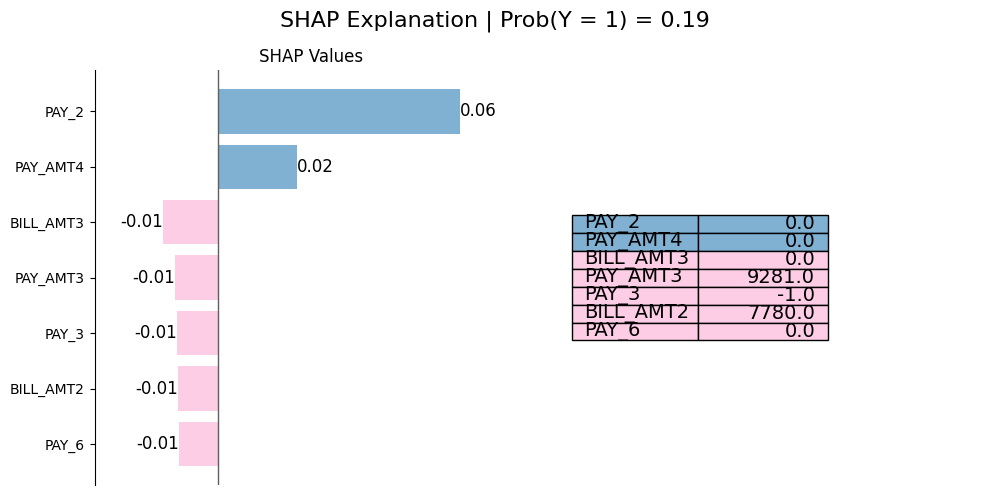

In [9]:
shap_explainer.plot_explanation(X_train.iloc[[2]])
prob = pipeline.predict_proba(X_train.iloc[[2]])[0, 1]
plt.suptitle(f"SHAP Explanation | Prob(Y = 1) = {prob:.2f}", fontsize = 16)

## MAPOCAM

In [10]:
X_train_positive = X_train[pipeline.predict(X_train) == 1]

In [19]:
mutable_features = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]

In [26]:
method = MAPOCAM(
    pipeline,
    X_train,
    mutable_features,
    target = 0,
    max_changes = 5,
    criteria = "percentile_changes",
    threshold=0.5,
    step_size = 0.01
)

In [27]:
cfs = method.fit(X_train_positive.iloc[[4]])

In [32]:
display_cfs(X_train_positive.iloc[[4]], cfs, pipeline)

,Original,CF 1,CF 0
PAY_AMT1,3775,0,1932
PAY_AMT3,1000,672,0
PAY_AMT5,994,994,671


### Dice

In [37]:
method = Dice(
    X_train,
    y_train,
    pipeline,
    n_cfs = 3,
    mutable_features = mutable_features,
)

In [38]:
cfs = method.fit(X_train_positive.iloc[[4]])

100%|██████████| 1/1 [00:01<00:00,  1.58s/it]


In [40]:
display_cfs(X_train_positive.iloc[[4]], cfs, pipeline) 

,Original,CF 0,CF 1,CF 2
PAY_AMT1,3775,0,0,0
PAY_AMT3,1000,0,0,0
PAY_AMT4,75,0,0,362
PAY_AMT5,994,0,410,500
